In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder


In [245]:
# Load Data
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")

In [246]:
# Show table
train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [247]:
# Replace ? with NaN
train = train.replace(" ?",np.nan)
test = test.replace(" ?",np.nan)

In [248]:
# Total Nulls
train.isna().count()

age               32561
workclass         32561
fnlwgt            32561
education         32561
education-num     32561
marital-status    32561
occupation        32561
relationship      32561
race              32561
sex               32561
capital-gain      32561
capital-loss      32561
hours-per-week    32561
native-country    32561
Income            32561
dtype: int64

In [249]:
# Calculating Duplicated Data
train.duplicated().sum()

np.int64(24)

In [250]:
# Removing Duplicated Data
train = train.drop_duplicates()

In [251]:
# Clean Column Names
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

In [252]:
# Separate features and target
x_train = train.drop("Income",axis=1)
y_train = train["Income"]

x_test = test.drop("Income",axis=1)
y_test = test["Income"]

In [253]:
# Clean target values
y_train = y_train.astype(str).str.strip().str.replace(".", "", regex=False)
y_test = y_test.astype(str).str.strip().str.replace(".", "", regex=False)

# Check values before encoding
print(y_train.unique())
print(y_test.unique())

<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str
<StringArray>
['<=50K', '>50K']
Length: 2, dtype: str


In [254]:
# Encode Target
y_train = y_train.map({"<=50K": 0, ">50K": 1})
y_test = y_test.map({"<=50K": 0, ">50K": 1})

In [255]:
train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [256]:
# Replace non-numerical Values with mode
# and the numerical with mean
for col in x_train.columns:
    if not pd.api.types.is_numeric_dtype(x_train[col]):  # any non-numeric → mode
        mode_val = x_train[col].mode()[0]
        x_train[col] = x_train[col].fillna(mode_val)
        x_test[col]  = x_test[col].fillna(mode_val)
    else:  # numeric → mean
        mean_val = x_train[col].mean()
        x_train[col] = x_train[col].fillna(mean_val)
        x_test[col]  = x_test[col].fillna(mean_val)

In [257]:
# Create net-capital first
x_train["net-capital"] = x_train["capital-gain"] - x_train["capital-loss"]
x_test["net-capital"]  = x_test["capital-gain"]  - x_test["capital-loss"]

In [258]:
# Drop Meaningless Features

############################### E7naaaa 3mlnaaa comments 3la race w sex w native


# x_train = x_train.drop(["education", "fnlwgt", "race", "capital-gain", "capital-loss","native-country","sex"], axis=1)
# x_test = x_test.drop(["education", "fnlwgt" , "race" , "capital-gain", "capital-loss","native-country","sex" ], axis=1)

x_train = x_train.drop(["education", "fnlwgt",  "capital-gain", "capital-loss"], axis=1)
x_test = x_test.drop(["education", "fnlwgt",  "capital-gain", "capital-loss"], axis=1)


In [259]:
x_train.isnull().sum()
x_test.isnull().sum()

age               0
workclass         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
hours-per-week    0
native-country    0
net-capital       0
dtype: int64

In [260]:
x_train

,age,workclass,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,net-capital
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,2174
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,0
32557,40,Private,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,0
32558,58,Private,9,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,0
32559,22,Private,9,Never-married,Adm-clerical,Own-child,White,Male,20,United-States,0


In [261]:

# cat_cols = ["workclass", "marital-status", "occupation", "relationship"]
cat_cols = ["workclass", "marital-status", "occupation", "relationship","race","sex","native-country"]
# OneHot Encoding
x_train = pd.get_dummies(x_train, columns=cat_cols,dtype=int)
x_test = pd.get_dummies(x_test, columns=cat_cols,dtype=int)

x_train, x_test = x_train.align(x_test, join='left', axis=1, fill_value=0)

In [262]:
x_train

,age,education-num,hours-per-week,net-capital,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,13,40,2174,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,13,13,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,7,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,13,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,40,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,58,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,22,9,20,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


Income                                1.000000
marital-status_ Married-civ-spouse    0.444609
relationship_ Husband                 0.400941
education-num                         0.335272
age                                   0.234037
                                        ...   
occupation_ Other-service            -0.156332
relationship_ Not-in-family          -0.188299
sex_ Female                          -0.215969
relationship_ Own-child              -0.228593
marital-status_ Never-married        -0.318285
Name: Income, Length: 88, dtype: float64


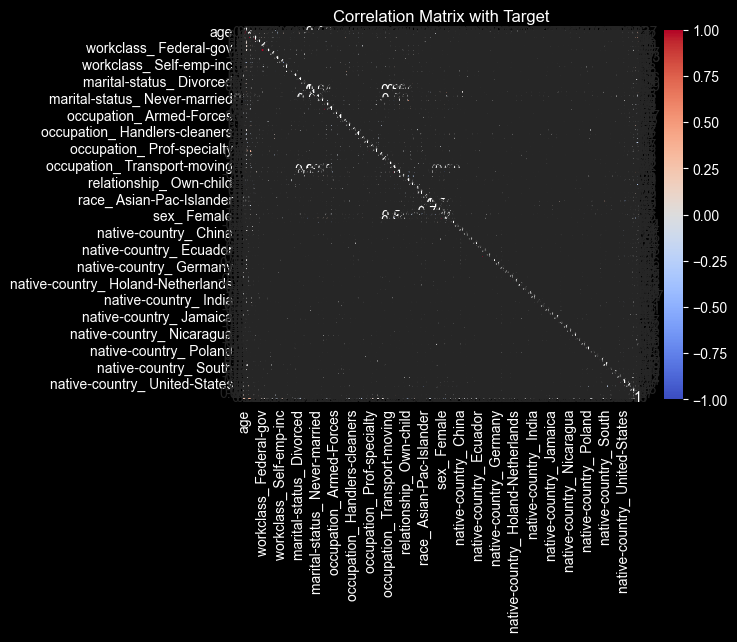

In [263]:
# Temporarily combine for correlation
train_df = pd.concat([x_train, y_train], axis=1)

# 1. Correlation with target only
corr = train_df.corr()
print(corr[y_train.name].sort_values(ascending=False))

# 2. Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix with Target')
plt.show()

In [264]:
# x_train = x_train.drop("sex", axis=1)
# x_test = x_test.drop("sex", axis=1)

In [265]:
x_train

,age,education-num,hours-per-week,net-capital,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,39,13,40,2174,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,50,13,13,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,0,0
2,38,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,53,7,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,28,13,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,12,38,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32557,40,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32558,58,9,40,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
32559,22,9,20,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0


In [266]:
scaler = MinMaxScaler()
x_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test  = pd.DataFrame(scaler.transform(x_test),      columns=x_test.columns)

In [267]:
# Logistic Model

# 1. Train the model
model = LogisticRegression(max_iter=10000)
model.fit(x_train, y_train)

# 2. Predict
y_pred = model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.8452


In [268]:
# SVM Model

# 1. Train the model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(x_train, y_train)

# 2. Predict
y_pred_svm = svm_model.predict(x_test)

# 3. Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")

# 4. Detailed report
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.8397
              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12435
           1       0.71      0.54      0.61      3846

    accuracy                           0.84     16281
   macro avg       0.79      0.74      0.76     16281
weighted avg       0.83      0.84      0.83     16281



In [269]:
# ── Decision Tree ──────────────────────────────────────
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)

print("===== Decision Tree =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt))


===== Decision Tree =====
Accuracy: 0.8217
              precision    recall  f1-score   support

           0       0.88      0.89      0.88     12435
           1       0.63      0.61      0.62      3846

    accuracy                           0.82     16281
   macro avg       0.75      0.75      0.75     16281
weighted avg       0.82      0.82      0.82     16281



In [270]:
# ── Random Forest ──────────────────────────────────────
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("===== Random Forest =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

===== Random Forest =====
Accuracy: 0.8434
              precision    recall  f1-score   support

           0       0.88      0.92      0.90     12435
           1       0.70      0.60      0.64      3846

    accuracy                           0.84     16281
   macro avg       0.79      0.76      0.77     16281
weighted avg       0.84      0.84      0.84     16281



In [271]:
# ── XGBoost ────────────────────────────────────────────
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)

print("===== XGBoost =====")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

===== XGBoost =====
Accuracy: 0.8719
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12435
           1       0.77      0.65      0.71      3846

    accuracy                           0.87     16281
   macro avg       0.83      0.80      0.81     16281
weighted avg       0.87      0.87      0.87     16281

